In [3]:
pip install faiss-cpu sentence-transformers pinecone -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 9.7 MB/s eta 0:00:00


In [4]:
import numpy as np
import faiss
import time
from sentence_transformers import SentenceTransformer
from pinecone import Pinecone, ServerlessSpec

In [6]:
texts = [
    "Document about AI simulations.",
    "Deep learning and neural networks.",
    "Vector databases and similarity search.",
    "Graph-based indexing methods.",
    "Clustering algorithms in machine learning."
]

In [7]:
# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
# Convert text → vectors
embeddings = model.encode(texts)
embeddings = np.array(embeddings).astype("float32")

dimension = embeddings.shape[1]
dimension

384

In [9]:
# --------------------------------------------
# 1️⃣ FLAT INDEX (Exact Search)
# --------------------------------------------
print("---- FAISS: Flat Index ----")

flat_index = faiss.IndexFlatL2(dimension)
flat_index.add(embeddings)

query = "AI systems"
query_vector = model.encode([query]).astype("float32")

k = 3
distances, indices = flat_index.search(query_vector, k)

for i in indices[0]:
    print(texts[i])

---- FAISS: Flat Index ----
Document about AI simulations.
Deep learning and neural networks.
Clustering algorithms in machine learning.


In [10]:
# --------------------------------------------
# 2️⃣ HNSW INDEX (Graph-based)
# --------------------------------------------
print("\n---- FAISS: HNSW Index ----")

hnsw_index = faiss.IndexHNSWFlat(dimension, 32)
hnsw_index.add(embeddings)

distances, indices = hnsw_index.search(query_vector, k)

for i in indices[0]:
    print(texts[i])



---- FAISS: HNSW Index ----
Document about AI simulations.
Deep learning and neural networks.
Clustering algorithms in machine learning.


In [11]:
# --------------------------------------------
# 3️⃣ IVF INDEX (Cluster-based)
# --------------------------------------------
print("\n---- FAISS: IVF Index ----")

nlist = 2  # number of clusters

quantizer = faiss.IndexFlatL2(dimension)
ivf_index = faiss.IndexIVFFlat(quantizer, dimension, nlist)

ivf_index.train(embeddings)
ivf_index.add(embeddings)

ivf_index.nprobe = 1  # number of clusters to search

distances, indices = ivf_index.search(query_vector, k)

for i in indices[0]:
    print(texts[i])



---- FAISS: IVF Index ----
Document about AI simulations.
Deep learning and neural networks.
Clustering algorithms in machine learning.


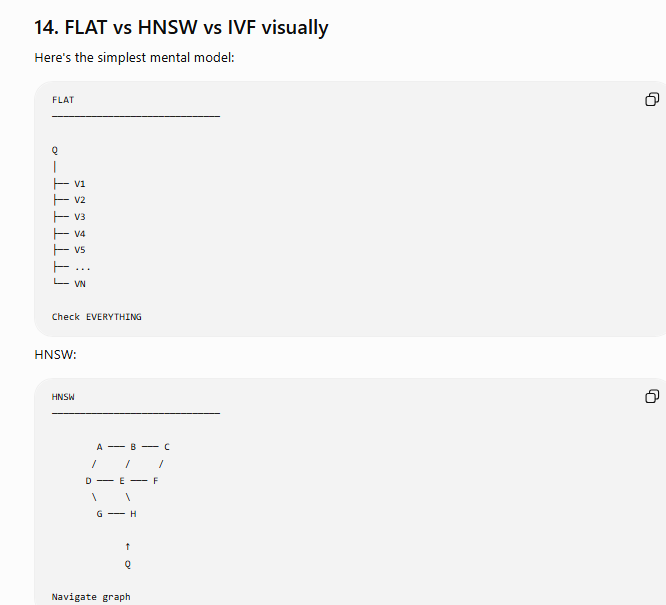

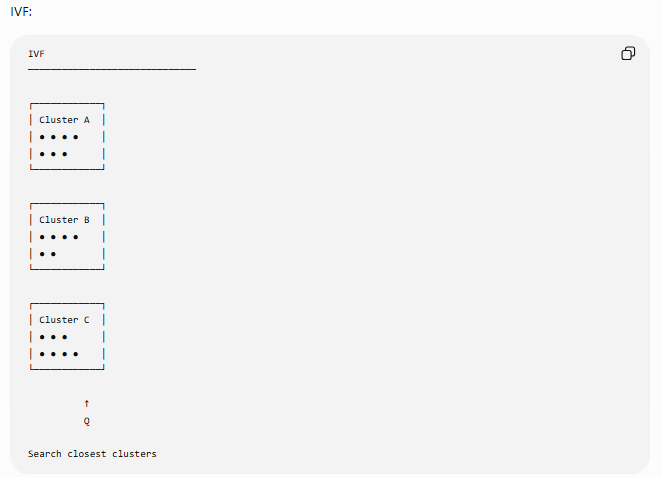

In [13]:
intents = [
    {
        "name": "CheckBalance",
        "description": "Handles requests where the customer wants to know their current account balance."
    },
    {
        "name": "TransferMoney",
        "description": "Handles requests where the customer wants to transfer money between accounts or send money to another person."
    },
    {
        "name": "BlockCard",
        "description": "Handles requests where the customer wants to block, freeze, or disable a lost or stolen card."
    },
    {
        "name": "ResetPassword",
        "description": "Handles requests where the customer wants to reset or recover their account password."
    },
    {
        "name": "TransactionHistory",
        "description": "Handles requests where the customer wants to view or obtain their recent account transactions."
    },
]

In [15]:
import pandas as pd
df = pd.DataFrame(intents)
df[["name", "description"]]

,name,description
0,CheckBalance,Handles requests where the customer wants to k...
1,TransferMoney,Handles requests where the customer wants to t...
2,BlockCard,Handles requests where the customer wants to b...
3,ResetPassword,Handles requests where the customer wants to r...
4,TransactionHistory,Handles requests where the customer wants to v...


In [16]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [17]:
descriptions = [ intent["description"] for intent in intents]

for i, description in enumerate(descriptions):
    print(f"{i}: {description}")

0: Handles requests where the customer wants to know their current account balance.
1: Handles requests where the customer wants to transfer money between accounts or send money to another person.
2: Handles requests where the customer wants to block, freeze, or disable a lost or stolen card.
3: Handles requests where the customer wants to reset or recover their account password.
4: Handles requests where the customer wants to view or obtain their recent account transactions.


In [18]:
intent_embeddings = model.encode(descriptions, convert_to_numpy=True, normalize_embeddings=True).astype("float32")

In [24]:
intent_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
normalize_embeddings=True

In [25]:
index.add(intent_embeddings)

print("Vectors in FAISS:", index.ntotal)

Vectors in FAISS: 5


In [26]:
def retrieve_intents(query, top_k=3):

    # Convert user utterance into vector
    query_embedding = model.encode( [query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")

    # Search FAISS
    scores, indices = index.search(query_embedding, top_k)

    results = []

    for score, idx in zip(scores[0],  indices[0]):
        intent = intents[idx]

        results.append({
            "intent": intent["name"],
            "description": intent["description"],
            "score": float(score)
        })

    return results

In [27]:
query = "I lost my card and need to freeze it"
results = retrieve_intents(query, top_k=3)
results

[{'intent': 'BlockCard',
  'description': 'Handles requests where the customer wants to block, freeze, or disable a lost or stolen card.',
  'score': 0.49361783266067505},
 {'intent': 'ResetPassword',
  'description': 'Handles requests where the customer wants to reset or recover their account password.',
  'score': 0.1838630735874176},
 {'intent': 'CheckBalance',
  'description': 'Handles requests where the customer wants to know their current account balance.',
  'score': 0.08266829699277878}]